In [13]:
import pandas as pd
import seaborn as sns
import pymongo
import os
import  matplotlib.pyplot as plt
from dotenv import load_dotenv  
load_dotenv() 
import os
from datetime import datetime
import numpy as np


In [3]:
local_file_path="/Users/anish/Fraud Detection/Notebooks/merged_transactions.parquet"
s3_uri="s3://fraud-detection-pipeline-anish-964043552068-ap-south-1-an/merged_transactions.parquet"

if os.path.exists(local_file_path):
    data=pd.read_parquet(local_file_path,engine="fastparquet")

else:
    data=pd.read_parquet(
        s3_uri,
        engine="fastparquet",
        storage_options={
            "key":os.getenv("AWS_ACCESS_KEY_ID"),
                   "secret":os.getenv("AWS_SECRET_ACCESS_KEY"),
                   "client_kwargs":{
                       "region_name":os.getenv("AWS_DEFAULT_REGION")
                    }
               }
           )
    data.to_parquet(local_file_path, engine="fastparquet", index=False)


In [4]:
df=data.copy()

In [5]:
df.head(10)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
5,2019-01-01 00:04:08,4767265376804500,"fraud_Stroman, Hudson and Erdman",gas_transport,94.63,Jennifer,Conner,F,4655 David Island,Dublin,...,40.3750,-75.2045,2158,Transport planner,1961-06-19,189a841a0a8ba03058526bcfe566aab5,1325376248,40.653382,-76.152667,0
6,2019-01-01 00:04:42,30074693890476,fraud_Rowe-Vandervort,grocery_net,44.54,Kelsey,Richards,F,889 Sarah Station Suite 624,Holcomb,...,37.9931,-100.9893,2691,Arboriculturist,1993-08-16,83ec1cc84142af6e2acf10c44949e720,1325376282,37.162705,-100.153370,0
7,2019-01-01 00:05:08,6011360759745864,fraud_Corwin-Collins,gas_transport,71.65,Steven,Williams,M,231 Flores Pass Suite 720,Edinburg,...,38.8432,-78.6003,6018,"Designer, multimedia",1947-08-21,6d294ed2cc447d2c71c7171a3d54967c,1325376308,38.948089,-78.540296,0
8,2019-01-01 00:05:18,4922710831011201,fraud_Herzog Ltd,misc_pos,4.27,Heather,Chase,F,6888 Hicks Stream Suite 954,Manor,...,40.3359,-79.6607,1472,Public affairs consultant,1941-03-07,fc28024ce480f8ef21a32d64c93a29f5,1325376318,40.351813,-79.958146,0
9,2019-01-01 00:06:01,2720830304681674,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,198.39,Melissa,Aguilar,F,21326 Taylor Squares Suite 708,Clarksville,...,36.5220,-87.3490,151785,Pathologist,1974-03-28,3b9014ea8fb80bd65de0b1463b00b00e,1325376361,37.179198,-87.485381,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   merchant               object 
 3   category               object 
 4   amt                    float64
 5   first                  object 
 6   last                   object 
 7   gender                 object 
 8   street                 object 
 9   city                   object 
 10  state                  object 
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    object 
 16  dob                    object 
 17  trans_num              object 
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
dtypes: float64(5), int

# Extracting the date time features for analysis and prediction




In [7]:
df['trans_date_trans_time']=pd.to_datetime(df['trans_date_trans_time'])
df['dob']=pd.to_datetime(df['dob'])
df['zip']=df['zip'].astype(str)

In [10]:
df['hour']=df['trans_date_trans_time'].dt.hour
df['day']=df['trans_date_trans_time'].dt.dayofweek
df['month']=df['trans_date_trans_time'].dt.month
df['year']=df['trans_date_trans_time'].dt.year
df['is_night']=df['hour'].apply(lambda x:1 if x>=23 or x<=4 else 0)
df['age']=df['age']=datetime.now().year-df['dob'].dt.year
df = df[df['zip'].str.len() == 5]


# Merchant Fraud Analysis

In [11]:
# This collapses your data into exactly 1 row per merchant
merchant_pivot = df.pivot_table(index="merchant", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()
merchant_pivot.columns = ['merchant', 'not_fraud', 'fraud']  # Rename columns for clarity
merchant_pivot.columns.name=None
print(merchant_pivot)

                             merchant  not_fraud  fraud
0                 fraud_Abbott-Rogahn       2465      4
1                fraud_Abbott-Steuber       2343      8
2            fraud_Abernathy and Sons       2353      4
3                   fraud_Abshire PLC       2566      8
4    fraud_Adams, Kovacek and Kuhlman       1270      5
..                                ...        ...    ...
688                fraud_Zemlak Group       1732     22
689  fraud_Zemlak, Tillman and Cremin       2393      3
690              fraud_Ziemann-Waters       2286     10
691      fraud_Zieme, Bode and Dooley       3438     10
692                  fraud_Zulauf LLC       2453      4

[693 rows x 3 columns]


### Weight of Evidence (WoE)
It is a powerful data transformation technique primarily used in risk modeling, credit scoring, and fraud detection. 
It measures the strength of a specific independent variable  in predicting a binary outcome (like fraud vs. not_fraud or default vs. good_payer).

### Weight of Evidence (WoE) Risk Scale
| WoE Value | What it Means | Risk Profile |
| :--- | :--- | :--- |
| **Positive Score ($>0$)** |The category has a higher share of legitimate transactions than fraudulent ones.| Safe / Low RiskZero 
| **Zero Score ($=0$)** |The category's fraud-to-legitimate ratio perfectly matches the global average.|Neutral / BaselineNegative 
| **Negative Score ($<0$)** |The category has a higher share of fraudulent transactions than legitimate ones.|Dangerous / High Risk

In [14]:
total_global_not_fraud = merchant_pivot['not_fraud'].sum()
total_global_fraud = merchant_pivot['fraud'].sum()

merchant_pivot['per_not_fraud'] = merchant_pivot['not_fraud']/total_global_not_fraud 
merchant_pivot['per_fraud'] = merchant_pivot['fraud']/total_global_fraud 

merchant_pivot['WoE'] = np.log((merchant_pivot['per_not_fraud'] + 1e-4) / (merchant_pivot['per_fraud'] + 1e-4))
df['WoE'] = np.log((merchant_pivot['per_not_fraud'] + 1e-4) / (merchant_pivot['per_fraud'] + 1e-4))

<Axes: xlabel='merchant'>

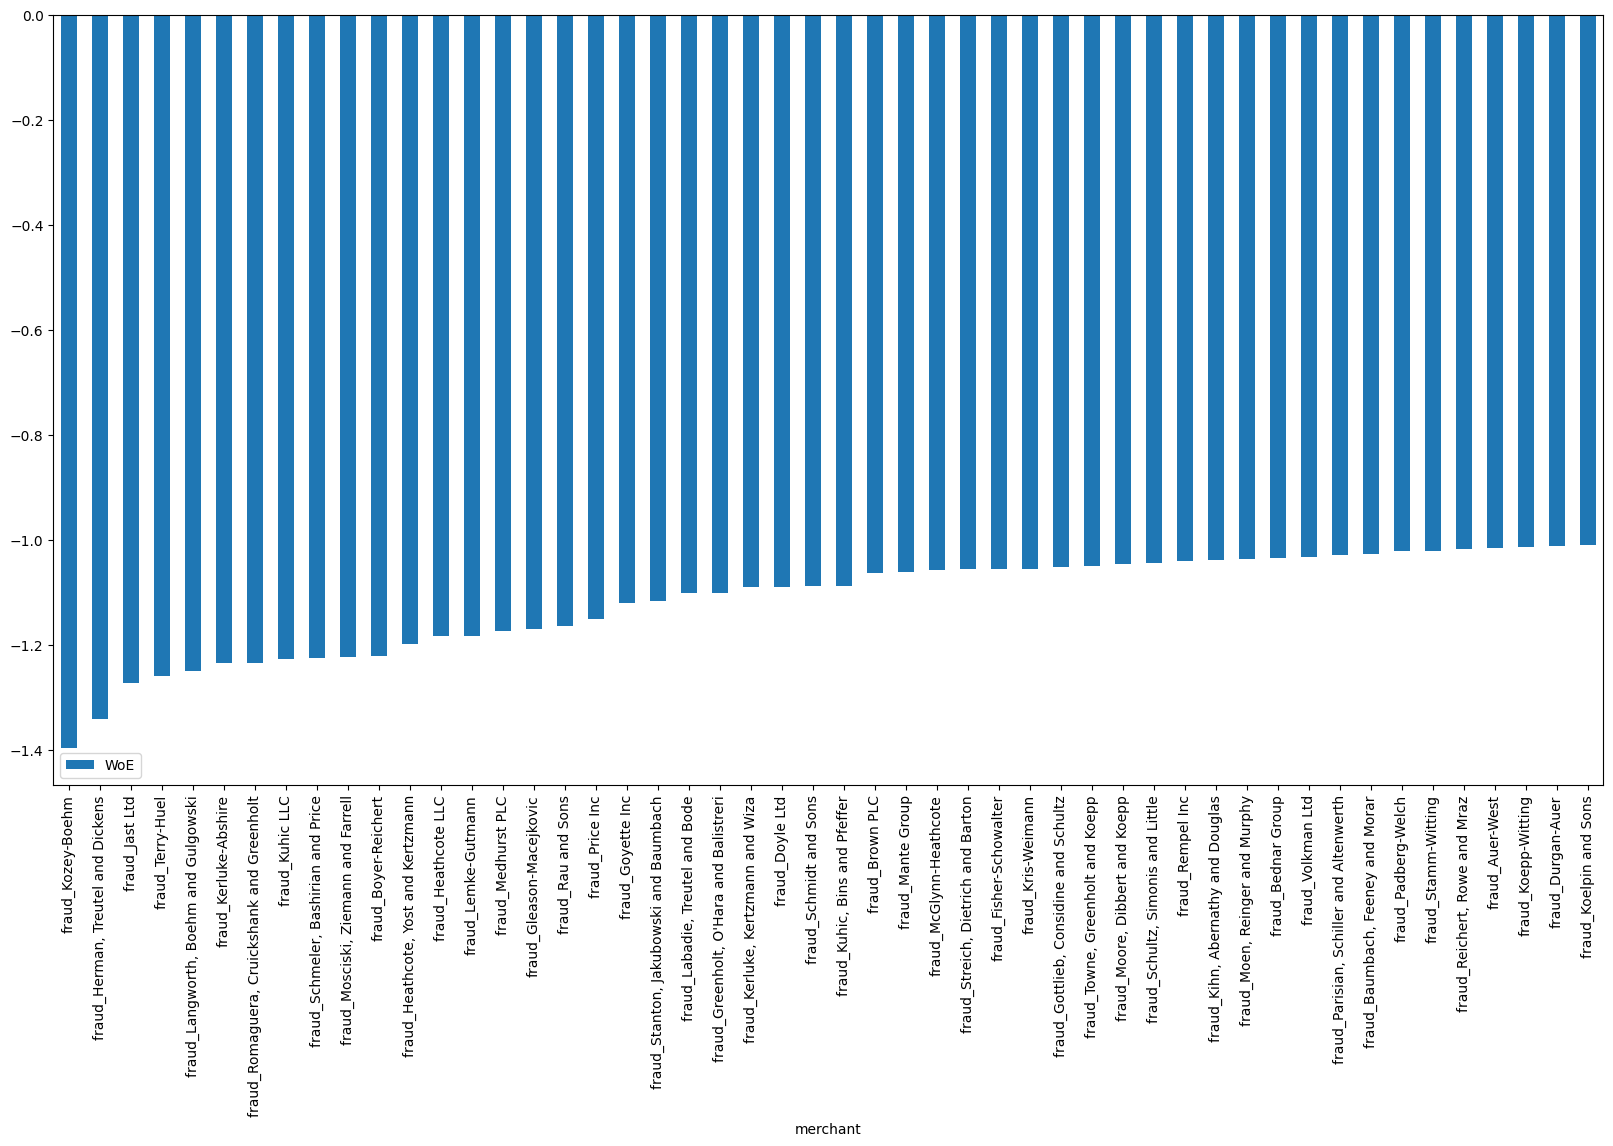

In [15]:
merchant_pivot.nsmallest(50,'WoE').plot(x='merchant',y='WoE',kind='bar',figsize=(20,10))

In [16]:
merchant_iv = ((merchant_pivot['per_not_fraud'] - merchant_pivot['per_fraud']) * merchant_pivot['WoE']).sum()
print(merchant_iv)

0.7510678270251419


In [17]:
category_pivot = df.pivot_table(index="category", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()
category_pivot.columns = ['category', 'not_fraud', 'fraud']
category_pivot.columns.name = None

# 2. Compute Global Totals
total_global_not_fraud = category_pivot['not_fraud'].sum()
total_global_fraud = category_pivot['fraud'].sum()

# 3. Calculate Proportions (Percentages)
category_pivot['per_not_fraud'] = category_pivot['not_fraud'] / total_global_not_fraud
category_pivot['per_fraud'] = category_pivot['fraud'] / total_global_fraud

# 4. Compute Weight of Evidence (WoE)
epsilon = 1e-4
category_pivot['WoE'] = np.log((category_pivot['per_not_fraud'] + epsilon) / (category_pivot['per_fraud'] + epsilon))

# 5. Map the Calculated WoE back to the Main DataFrame (FIXED)
category_woe_dict = dict(zip(category_pivot['category'], category_pivot['WoE']))
df['cat_woe'] = df['category'].map(category_woe_dict)

# 6. Calculate and Print Total Information Value (IV)
category_iv = ((category_pivot['per_not_fraud'] - category_pivot['per_fraud']) * category_pivot['WoE']).sum()
print(f"Category IV: {category_iv:.4f}")

Category IV: 0.7289


<Axes: xlabel='category'>

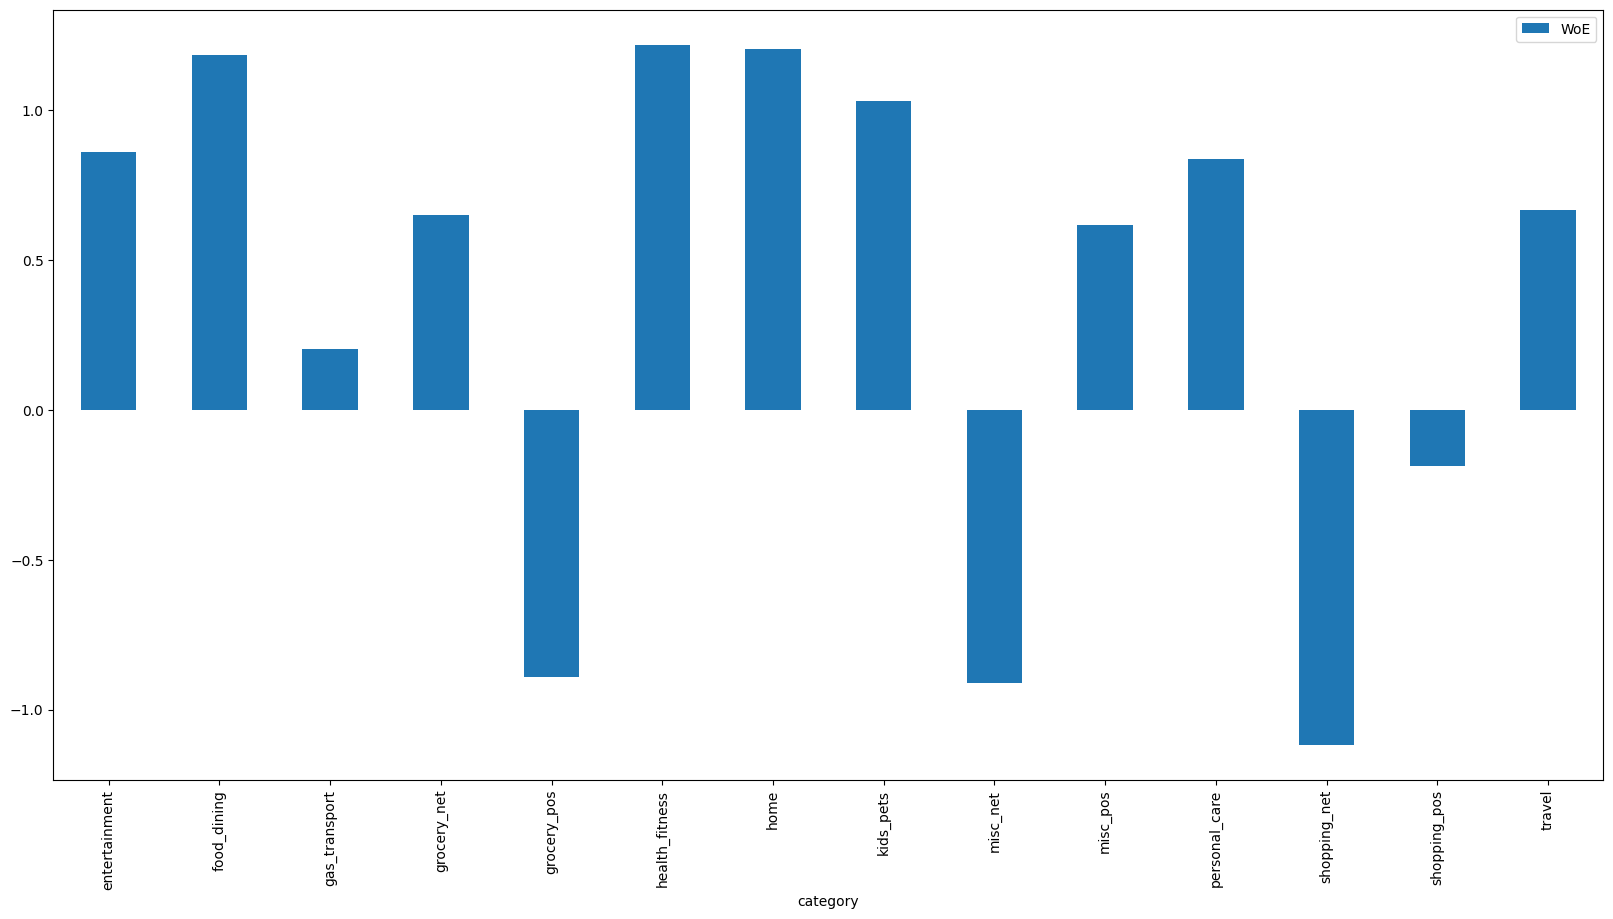

In [18]:
category_pivot.plot(x='category',y='WoE',kind='bar',figsize=(20,10))

In [19]:
import numpy as np
import pandas as pd

# 1. Create Pivot Table and Calculate Row Counts
city_pivot = df.pivot_table(index="city", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()
city_pivot.columns = ['city', 'not_fraud', 'fraud']
city_pivot.columns.name = None

# 2. Compute Global Totals
total_global_not_fraud = city_pivot['not_fraud'].sum()
total_global_fraud = city_pivot['fraud'].sum()

# 3. Calculate Proportions (Percentages)
city_pivot['per_not_fraud'] = city_pivot['not_fraud'] / total_global_not_fraud
city_pivot['per_fraud'] = city_pivot['fraud'] / total_global_fraud

# 4. Compute Weight of Evidence (WoE)
epsilon = 1e-4
city_pivot['WoE'] = np.log((city_pivot['per_not_fraud'] + epsilon) / (city_pivot['per_fraud'] + epsilon))

# 5. Map the Calculated WoE back to the Main DataFrame (FIXED)
city_woe_dict = dict(zip(city_pivot['city'], city_pivot['WoE']))
df['city_woe'] = df['city'].map(city_woe_dict)

# 6. Calculate and Print Total Information Value (IV)
city_iv = ((city_pivot['per_not_fraud'] - city_pivot['per_fraud']) * city_pivot['WoE']).sum()
print(f"City IV: {city_iv:.4f}")

City IV: 0.5938


In [20]:
import numpy as np
import pandas as pd

# 1. Create Pivot Table and Calculate Row Counts
category_pivot = df.pivot_table(index="category", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()
category_pivot.columns = ['category', 'not_fraud', 'fraud']
category_pivot.columns.name = None

# 2. Compute Global Totals
total_global_not_fraud = category_pivot['not_fraud'].sum()
total_global_fraud = category_pivot['fraud'].sum()

# 3. Calculate Proportions (Percentages)
category_pivot['per_not_fraud'] = category_pivot['not_fraud'] / total_global_not_fraud
category_pivot['per_fraud'] = category_pivot['fraud'] / total_global_fraud

# 4. Compute Weight of Evidence (WoE)
epsilon = 1e-4
category_pivot['WoE'] = np.log((category_pivot['per_not_fraud'] + epsilon) / (category_pivot['per_fraud'] + epsilon))

# 5. Map the Calculated WoE back to the Main DataFrame (FIXED)
category_woe_dict = dict(zip(category_pivot['category'], category_pivot['WoE']))
df['cat_woe'] = df['category'].map(category_woe_dict)

# 6. Calculate and Print Total Information Value (IV)
category_iv = ((category_pivot['per_not_fraud'] - category_pivot['per_fraud']) * category_pivot['WoE']).sum()
print(f"Category IV: {category_iv:.4f}")

Category IV: 0.7289


In [21]:
import numpy as np
import pandas as pd

# 1. Create Pivot Table and Calculate Row Counts
age_pivot = df.pivot_table(index="age", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()
age_pivot.columns = ['age', 'not_fraud', 'fraud']
age_pivot.columns.name = None

# 2. Compute Global Totals
total_global_not_fraud = age_pivot['not_fraud'].sum()
total_global_fraud = age_pivot['fraud'].sum()

# 3. Calculate Proportions (Percentages)
age_pivot['per_not_fraud'] = age_pivot['not_fraud'] / total_global_not_fraud
age_pivot['per_fraud'] = age_pivot['fraud'] / total_global_fraud

# 4. Compute Weight of Evidence (WoE)
epsilon = 1e-4
age_pivot['WoE'] = np.log((age_pivot['per_not_fraud'] + epsilon) / (age_pivot['per_fraud'] + epsilon))

# 5. Map the Calculated WoE back to the Main DataFrame (FIXED)
age_woe_dict = dict(zip(age_pivot['age'], age_pivot['WoE']))
df['age_woe'] = df['age'].map(age_woe_dict)

# 6. Calculate and Print Total Information Value (IV)
age_iv = ((age_pivot['per_not_fraud'] - age_pivot['per_fraud']) * age_pivot['WoE']).sum()
print(f"Age IV: {age_iv:.4f}")

Age IV: 0.1091


In [22]:
import numpy as np
import pandas as pd

# 1. Create Pivot Table and Calculate Row Counts
job_pivot = df.pivot_table(index="job", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()
job_pivot.columns = ['job', 'not_fraud', 'fraud']
job_pivot.columns.name = None

# 2. Compute Global Totals
total_global_not_fraud = job_pivot['not_fraud'].sum()
total_global_fraud = job_pivot['fraud'].sum()

# 3. Calculate Proportions (Percentages)
job_pivot['per_not_fraud'] = job_pivot['not_fraud'] / total_global_not_fraud
job_pivot['per_fraud'] = job_pivot['fraud'] / total_global_fraud

# 4. Compute Weight of Evidence (WoE)
epsilon = 1e-4
job_pivot['WoE'] = np.log((job_pivot['per_not_fraud'] + epsilon) / (job_pivot['per_fraud'] + epsilon))

# 5. Map the Calculated WoE back to the Main DataFrame (FIXED)
job_woe_dict = dict(zip(job_pivot['job'], job_pivot['WoE']))
df['job_woe'] = df['job'].map(job_woe_dict)

# 6. Calculate and Print Total Information Value (IV)
job_iv = ((job_pivot['per_not_fraud'] - job_pivot['per_fraud']) * job_pivot['WoE']).sum()
print(f"Job IV: {job_iv:.4f}")

Job IV: 0.3231


In [23]:
import numpy as np
import pandas as pd

# 1. Create Pivot Table and Calculate Row Counts
zip_pivot = df.pivot_table(index="zip", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()
zip_pivot.columns = ['zip', 'not_fraud', 'fraud']
zip_pivot.columns.name = None

# 2. Compute Global Totals
total_global_not_fraud = zip_pivot['not_fraud'].sum()
total_global_fraud = zip_pivot['fraud'].sum()

# 3. Calculate Proportions (Percentages)
zip_pivot['per_not_fraud'] = zip_pivot['not_fraud'] / total_global_not_fraud
zip_pivot['per_fraud'] = zip_pivot['fraud'] / total_global_fraud

# 4. Compute Weight of Evidence (WoE)
epsilon = 1e-4
zip_pivot['WoE'] = np.log((zip_pivot['per_not_fraud'] + epsilon) / (zip_pivot['per_fraud'] + epsilon))

# 5. Map the Calculated WoE back to the Main DataFrame (FIXED)
zip_woe_dict = dict(zip(zip_pivot['zip'], zip_pivot['WoE']))
df['zip_woe'] = df['zip'].map(zip_woe_dict)

# 6. Calculate and Print Total Information Value (IV)
zip_iv = ((zip_pivot['per_not_fraud'] - zip_pivot['per_fraud']) * zip_pivot['WoE']).sum()
print(f"Zip IV: {zip_iv:.4f}")

Zip IV: 0.6713


In [24]:
df['amt_bins'] = pd.qcut(df['amt'], q=5, labels=['Bin 1', 'Bin 2', 'Bin 3', 'Bin 4', 'Bin 5'])

amt_bins_pivot = df.pivot_table(index="amt_bins", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()
amt_bins_pivot.columns = ['amt_bins', 'not_fraud', 'fraud']
amt_bins_pivot.columns.name = None

# 2. Compute Global Totals
total_global_not_fraud = amt_bins_pivot['not_fraud'].sum()
total_global_fraud = amt_bins_pivot['fraud'].sum()

# 3. Calculate Proportions (Percentages)
amt_bins_pivot['per_not_fraud'] = amt_bins_pivot['not_fraud'] / total_global_not_fraud
amt_bins_pivot['per_fraud'] = amt_bins_pivot['fraud'] / total_global_fraud

# 4. Compute Weight of Evidence (WoE)
epsilon = 1e-4
amt_bins_pivot['WoE'] = np.log((amt_bins_pivot['per_not_fraud'] + epsilon) / (amt_bins_pivot['per_fraud'] + epsilon))

# 5. Map the Calculated WoE back to the Main DataFrame (FIXED)
amt_bins_woe_dict = dict(zip(amt_bins_pivot['amt_bins'], amt_bins_pivot['WoE']))
df['amt_bins_woe'] = df['amt_bins'].map(amt_bins_woe_dict)

# 6. Calculate and Print Total Information Value (IV)
amt_bins_iv = ((amt_bins_pivot['per_not_fraud'] - amt_bins_pivot['per_fraud']) * amt_bins_pivot['WoE']).sum()
print(f"Amount Bins IV: {amt_bins_iv:.4f}")


Amount Bins IV: 3.0060


/var/folders/12/_20q158903d9hmlcjr_qn2z80000gn/T/ipykernel_68708/1386262355.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  amt_bins_pivot = df.pivot_table(index="amt_bins", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()


In [25]:
df['pop_bins'] = pd.qcut(df['city_pop'], q=5, labels=['Bin 1', 'Bin 2', 'Bin 3', 'Bin 4', 'Bin 5'])

pop_bins_pivot = df.pivot_table(index="pop_bins", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()
pop_bins_pivot.columns = ['pop_bins', 'not_fraud', 'fraud']
pop_bins_pivot.columns.name = None

# 2. Compute Global Totals
total_global_not_fraud = pop_bins_pivot['not_fraud'].sum()
total_global_fraud = pop_bins_pivot['fraud'].sum()

# 3. Calculate Proportions (Percentages)
pop_bins_pivot['per_not_fraud'] = pop_bins_pivot['not_fraud'] / total_global_not_fraud
pop_bins_pivot['per_fraud'] = pop_bins_pivot['fraud'] / total_global_fraud

# 4. Compute Weight of Evidence (WoE)
epsilon = 1e-4
pop_bins_pivot['WoE'] = np.log((pop_bins_pivot['per_not_fraud'] + epsilon) / (pop_bins_pivot['per_fraud'] + epsilon))

# 5. Map the Calculated WoE back to the Main DataFrame (FIXED)
pop_bins_woe_dict = dict(zip(pop_bins_pivot['pop_bins'], pop_bins_pivot['WoE']))
df['pop_bins_woe'] = df['pop_bins'].map(pop_bins_woe_dict)

# 6. Calculate and Print Total Information Value (IV)
pop_bins_iv = ((pop_bins_pivot['per_not_fraud'] - pop_bins_pivot['per_fraud']) * pop_bins_pivot['WoE']).sum()
print(f"Population Bins IV: {pop_bins_iv:.4f}")


Population Bins IV: 0.0020


/var/folders/12/_20q158903d9hmlcjr_qn2z80000gn/T/ipykernel_68708/1578636524.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pop_bins_pivot = df.pivot_table(index="pop_bins", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()


<Axes: title={'center': 'Weight of Evidence by Amount Bins'}, xlabel='amt_bins'>

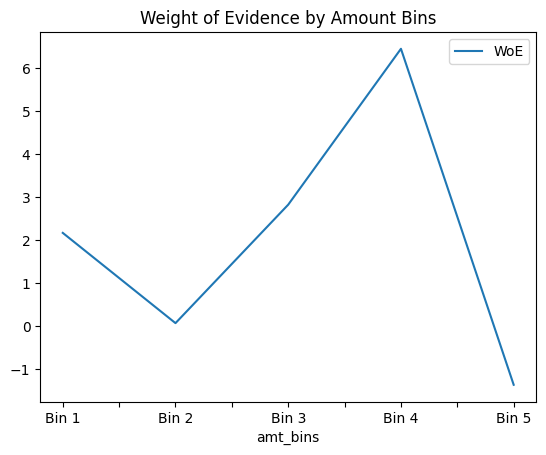

In [26]:
amt_bins_pivot.plot(kind='line',x='amt_bins',y='WoE',title='Weight of Evidence by Amount Bins')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1736005 entries, 0 to 1852393
Data columns (total 38 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   trans_date_trans_time  datetime64[ns]
 1   cc_num                 int64         
 2   merchant               object        
 3   category               object        
 4   amt                    float64       
 5   first                  object        
 6   last                   object        
 7   gender                 object        
 8   street                 object        
 9   city                   object        
 10  state                  object        
 11  zip                    object        
 12  lat                    float64       
 13  long                   float64       
 14  city_pop               int64         
 15  job                    object        
 16  dob                    datetime64[ns]
 17  trans_num              object        
 18  unix_time              int6

In [28]:
category_pivot.nsmallest(10, 'WoE')

,category,not_fraud,fraud,per_not_fraud,per_fraud,WoE
11,shopping_net,128789,2064,0.074576,0.228142,-1.117252
8,misc_net,83874,1094,0.048567,0.120924,-0.910978
4,grocery_pos,162942,2085,0.094352,0.230463,-0.892433
12,shopping_pos,155308,982,0.089932,0.108544,-0.187919
2,gas_transport,174670,746,0.101143,0.082458,0.204021
9,misc_pos,106611,301,0.061733,0.033271,0.616766
3,grocery_net,60867,166,0.035245,0.018349,0.650173
13,travel,54105,145,0.031330,0.016027,0.667231
10,personal_care,121881,276,0.070576,0.030507,0.836859
0,entertainment,125432,277,0.072632,0.030618,0.861933


<Axes: title={'center': 'Distribution of Transaction Amounts'}>

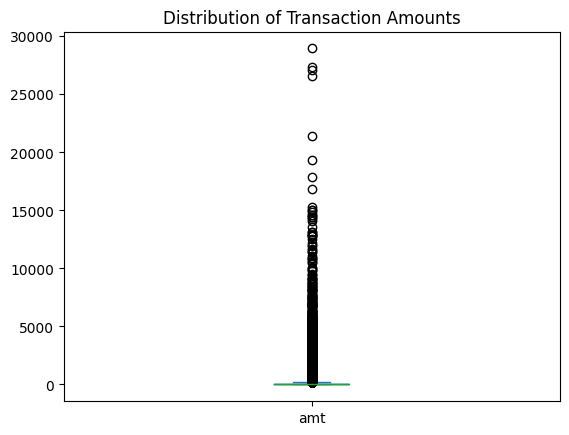

In [29]:
df["amt"].plot(kind="box", title="Distribution of Transaction Amounts")

<Axes: title={'center': 'Zoomed Distribution of Transaction Amounts'}>

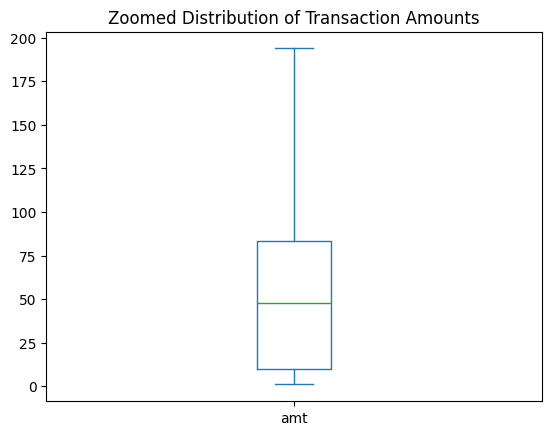

In [30]:
# Force the plot to hide those extreme outlier circles so you can see the box structure
df['amt'].plot(kind="box", showfliers=False, title="Zoomed Distribution of Transaction Amounts")

In [31]:
# Pass a list of the exact percentiles you want to look at
df["amt"].quantile([0.25, 0.50, 0.75, 0.90, 0.99])

0.25      9.6800
0.50     47.5200
0.75     83.3300
0.90    137.0300
0.99    538.1892
Name: amt, dtype: float64

In [32]:
types=['line', 'bar', 'barh', 'kde', 'density', 'area', 'hist', 'box', 'pie', 'scatter', 'hexbin']

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1736005 entries, 0 to 1852393
Data columns (total 38 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   trans_date_trans_time  datetime64[ns]
 1   cc_num                 int64         
 2   merchant               object        
 3   category               object        
 4   amt                    float64       
 5   first                  object        
 6   last                   object        
 7   gender                 object        
 8   street                 object        
 9   city                   object        
 10  state                  object        
 11  zip                    object        
 12  lat                    float64       
 13  long                   float64       
 14  city_pop               int64         
 15  job                    object        
 16  dob                    datetime64[ns]
 17  trans_num              object        
 18  unix_time              int6

The Leading Zero Issue:
 If you store a ZIP code as an integer (int64),
 Python will automatically drop any leading zeros. For example, the Boston ZIP code 02108 will become 2108, which corrupts your data and breaks geographical matching.

In [40]:
merchant_summary=pd.crosstab(
    df["merchant"],df["is_fraud"]
).reset_index().rename(columns={0: "no_fraud", 1: "fraud"})

In [41]:
print(merchant_summary)

is_fraud                          merchant  no_fraud  fraud
0                      fraud_Abbott-Rogahn      2465      4
1                     fraud_Abbott-Steuber      2343      8
2                 fraud_Abernathy and Sons      2353      4
3                        fraud_Abshire PLC      2566      8
4         fraud_Adams, Kovacek and Kuhlman      1270      5
..                                     ...       ...    ...
688                     fraud_Zemlak Group      1732     22
689       fraud_Zemlak, Tillman and Cremin      2393      3
690                   fraud_Ziemann-Waters      2286     10
691           fraud_Zieme, Bode and Dooley      3438     10
692                       fraud_Zulauf LLC      2453      4

[693 rows x 3 columns]


In [42]:
features=['hour','day','month','year']
for f in features:
     print(df[f].value_counts().sort_values())


hour
4     56172
5     56253
9     56294
11    56437
10    56569
7     56570
6     56644
8     56754
0     56771
2     56878
3     57118
1     57412
14    87222
20    87229
12    87490
19    87570
17    87601
13    87609
15    87733
21    87941
18    88159
16    88408
22    89368
23    89803
Name: count, dtype: int64
day
2    172465
3    193757
4    201481
5    246667
1    253704
6    322069
0    345862
Name: count, dtype: int64
month
2      91592
1      98050
4     126655
10    129459
9     131291
11    133908
3     134667
5     137576
7     161643
6     162828
8     165106
12    263230
Name: count, dtype: int64
year
2019    866348
2020    869657
Name: count, dtype: int64


In [45]:
import folium
from folium.plugins import HeatMap

fraud_df = df[df['is_fraud'] == 1].dropna(subset=['lat', 'long'])


base_map = folium.Map(location=[37.0902, -95.7129], zoom_start=4, tiles="CartoDB positron")

heat_data = fraud_df[['lat', 'long']].values.tolist()

HeatMap(heat_data, radius=10, max_zoom=13).add_to(base_map)
base_map

In [46]:
R = 6,371
lat1=np.radians(df['lat'])
lon1=np.radians(df['long'])
lat2=np.radians(df['merch_lat'])
lon2=np.radians(df['merch_long'])

dlat=lat2-lat1
dlong=lon2-lon1

a=np.sin(dlat/2)**2+np.cos(lat1)*np.cos(lat2)*np.sin(dlong/2)**2
d=2*np.arcsin(np.sqrt(a))
df['distance']=6371*d

<Axes: >

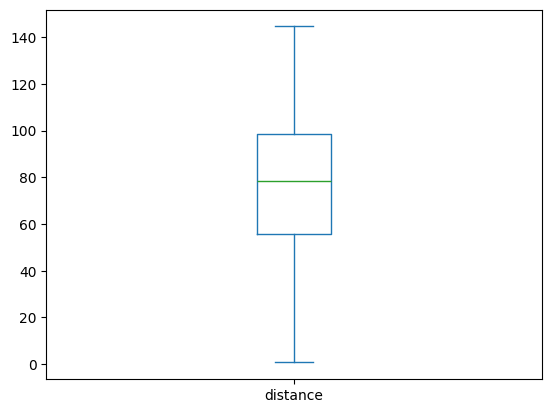

In [47]:
data=df[df['is_fraud']==1]
data.plot(kind='box',y='distance')

<Axes: >

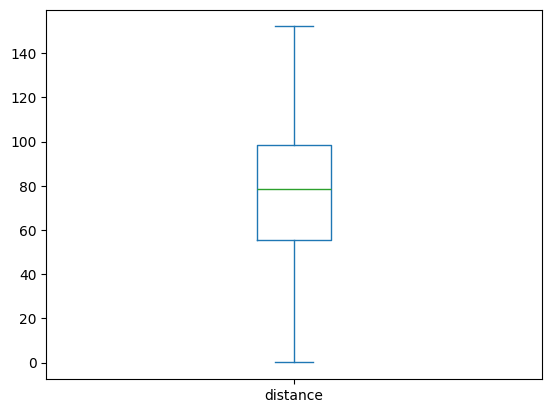

In [48]:
data=df[df['is_fraud']==0]
data.plot(kind='box',y='distance')

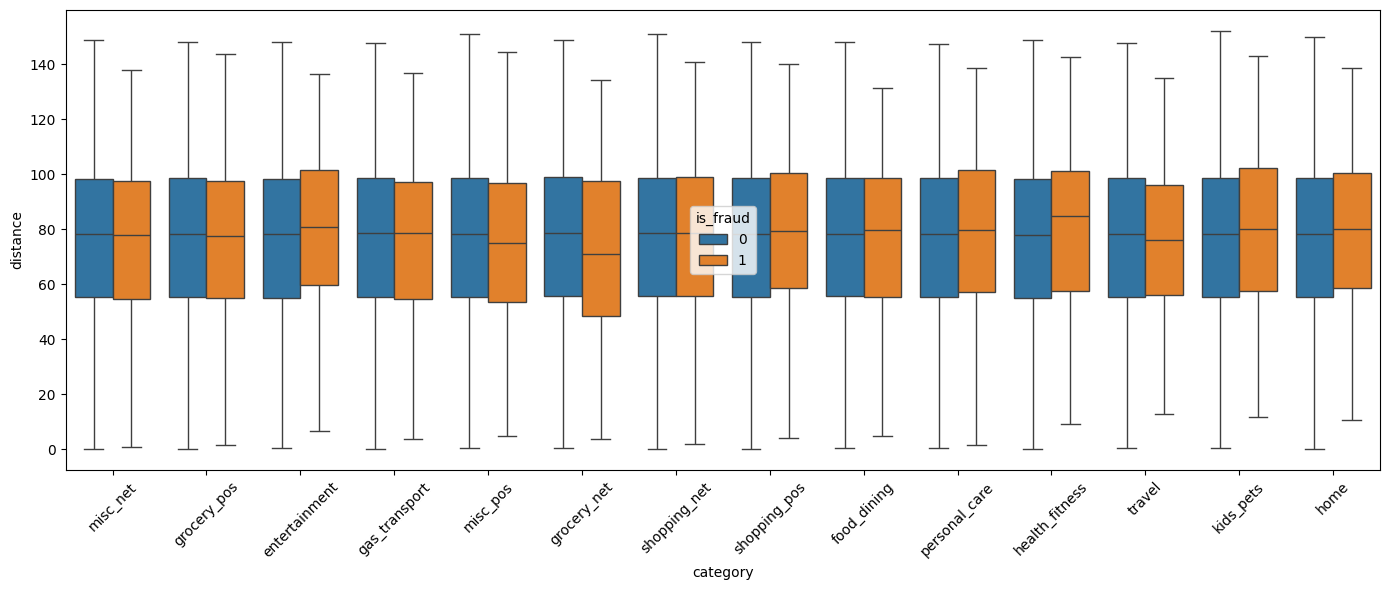

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
# Create a boxplot grouped by category, colored by fraud status
sns.boxplot(data=df, x='category', y='distance', hue='is_fraud')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
data['distance'].min()

np.float64(0.022254515638533652)

In [51]:
numerical_cols = ['city_pop','is_fraud']

corr_matrix = df[numerical_cols].corr()

In [ ]:
corr_matrix

,city_pop,is_fraud
city_pop,1.000000,0.000332
is_fraud,0.000332,1.000000


In [52]:
import folium
from folium.plugins import HeatMap

fraud_df = df[df['is_fraud'] == 1].dropna(subset=['lat', 'long'])


base_map = folium.Map(location=[37.0902, -95.7129], zoom_start=4, tiles="CartoDB positron")

heat_data = fraud_df[['lat', 'long']].values.tolist()

HeatMap(heat_data, radius=10, max_zoom=13).add_to(base_map)

# base_map.save("fraud_hotspots_map.html")
base_map

In [ ]:
    city=df['city']


In [ ]:
city

0          Moravian Falls
1                  Orient
2              Malad City
3                 Boulder
4                Doe Hill
                ...      
1852389             Luray
1852390      Lake Jackson
1852391           Burbank
1852392              Mesa
1852393            Edmond
Name: city, Length: 1736005, dtype: object

In [53]:
base_map

In [54]:
state_fraud_rate=df.groupby("state")["is_fraud"].value_counts()\
                   .reset_index()\
                   .pivot(index="state",columns="is_fraud",values="count")[1]\
                   .reset_index().sort_values(by=1,ascending=False)\
                   .reset_index(drop=True)

<Axes: xlabel='age', ylabel='Fraud Count'>

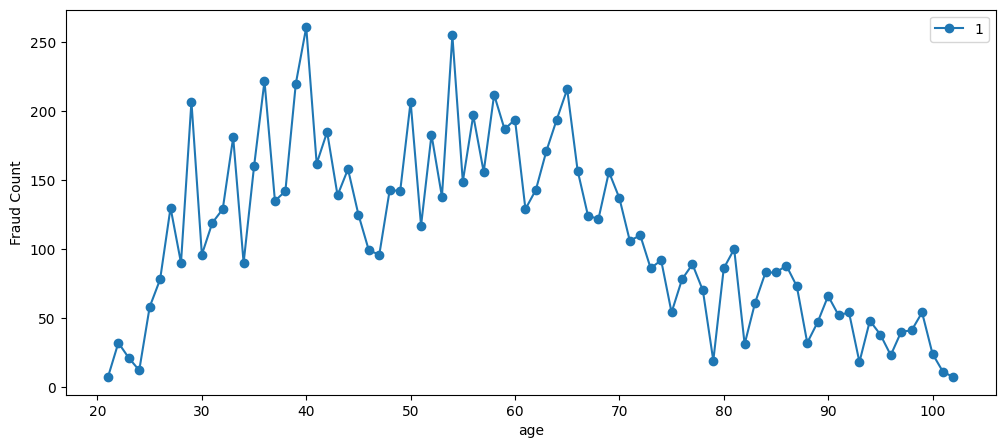

In [56]:
# Swapping 'bar' to 'line' makes individual ages much cleaner to look at
df.groupby('age')['is_fraud'].value_counts()\
  .reset_index()\
  .pivot(index='age', columns='is_fraud', values='count')\
  .reset_index()\
  .sort_values(by='age')\
  .reset_index(drop=True)\
  .plot(kind='line', x='age', y=1, marker='o', figsize=(12, 5), ylabel='Fraud Count')

<Axes: xlabel='age', ylabel='Fraud Count'>

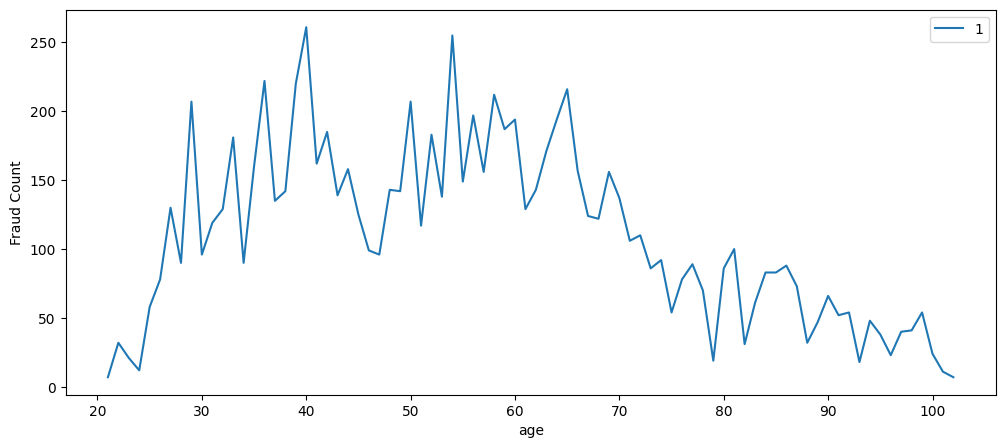

In [57]:
# Swapping 'bar' to 'line' makes individual ages much cleaner to look at
df.groupby('age')['is_fraud'].value_counts()\
  .reset_index()\
  .pivot(index='age', columns='is_fraud', values='count')\
  .reset_index()\
  .sort_values(by='age')\
  .reset_index(drop=True)\
  .plot(kind='line', x='age', y=1,figsize=(12, 5), ylabel='Fraud Count')

<Axes: ylabel='Frequency'>

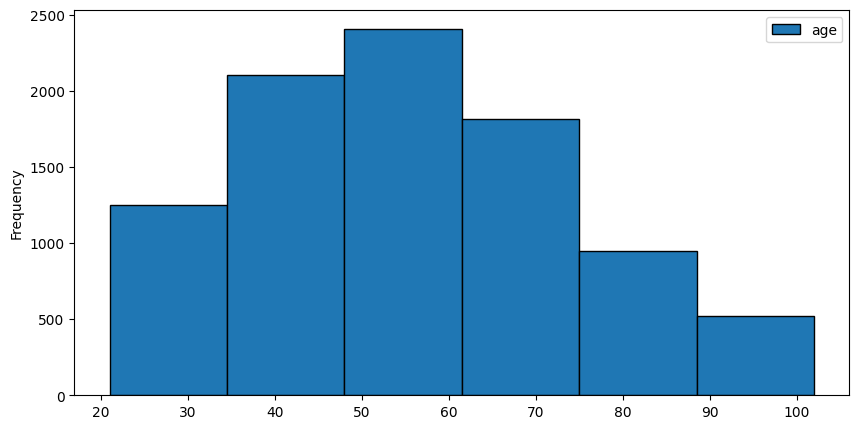

In [58]:
# 1. Filter the rows inside the main DataFrame
fraud_only_df = df[df['is_fraud'] == 1]
fraud_only_df.plot(kind='hist', y='age', bins=6, edgecolor='black', figsize=(10, 5))

<Axes: xlabel='zip', ylabel='Fraud Count'>

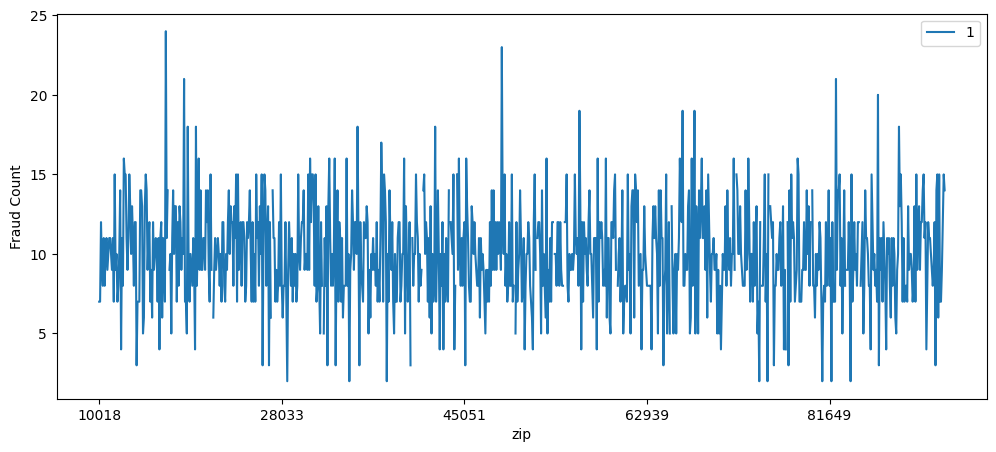

In [61]:
# Swapping 'bar' to 'line' makes individual ages much cleaner to look at
df.groupby('zip')['is_fraud'].value_counts()\
  .reset_index()\
  .pivot(index='zip', columns='is_fraud', values='count')\
  .reset_index()\
  .sort_values(by='zip')\
  .reset_index(drop=True)\
  .plot(kind='line', x='zip', y=1,figsize=(12, 5), ylabel='Fraud Count')

In [62]:
df['zip']=df['zip'].astype(str)
df = df[df['zip'].str.len() == 5]

In [63]:
df['zip']

0          28654
1          99160
2          83252
3          59632
4          24433
           ...  
1852389    63453
1852390    77566
1852391    99323
1852392    83643
1852393    73034
Name: zip, Length: 1736005, dtype: object

In [64]:
import folium
from folium.plugins import HeatMap

zip_fraud = df.groupby('zip').agg(
    fraud_count=('is_fraud', 'sum'),
    lat=('lat', 'mean'),
    long=('long', 'mean')
).reset_index()

zip_fraud = zip_fraud[zip_fraud['fraud_count'] > 0]

zip_map = folium.Map(location=[37.0902, -95.7129], zoom_start=4, tiles="CartoDB positron")

# 3. Add markers or a HeatMap using the coordinates
# Option A: A HeatMap weighted by the amount of fraud per zip code
heat_data = zip_fraud[['lat', 'long', 'fraud_count']].values.tolist()
HeatMap(heat_data, radius=15, max_zoom=10).add_to(zip_map)

# Save and display your map
zip_map.save("zip_fraud_map.html")

In [65]:
zip_fraud

,zip,fraud_count,lat,long
0,10018,7,40.7547,-73.9925
1,10039,7,40.8265,-73.9383
2,10162,12,40.7699,-73.9511
3,10280,9,40.7105,-74.0163
4,10463,8,40.8798,-73.9067
...,...,...,...,...
922,99323,7,46.1966,-118.9017
923,99746,9,65.6899,-156.2920
924,99747,12,66.6933,-153.9940
925,99783,15,64.7556,-165.6723


In [67]:
import folium
from folium.plugins import HeatMap

fraud_df = df[df['is_fraud'] == 1].dropna(subset=['lat', 'long'])


base_map = folium.Map(location=[37.0902, -95.7129], zoom_start=4, tiles="CartoDB positron")

heat_data = fraud_df[['merch_lat', 'merch_long']].values.tolist()

HeatMap(heat_data, radius=10, max_zoom=13).add_to(base_map)

base_map.save("merch_fraud_hotspots_map.html")
base_map

### Temporal Analysis (Time-Based Fraud Patterns).

In [68]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'hour', 'day', 'month', 'year', 'is_night',
       'age', 'WoE', 'cat_woe', 'city_woe', 'age_woe', 'job_woe', 'zip_woe',
       'amt_bins', 'amt_bins_woe', 'pop_bins', 'pop_bins_woe', 'distance'],
      dtype='object')

In [69]:
import numpy as np
import pandas as pd

hour_pivot = df.pivot_table(index="hour", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()
hour_pivot.columns = ['hour', 'not_fraud', 'fraud']
hour_pivot.columns.name = None

total_global_not_fraud = hour_pivot['not_fraud'].sum()
total_global_fraud = hour_pivot['fraud'].sum()

hour_pivot['per_not_fraud'] = hour_pivot['not_fraud'] / total_global_not_fraud
hour_pivot['per_fraud'] = hour_pivot['fraud'] / total_global_fraud

epsilon = 1e-4
hour_pivot['WoE'] = np.log((hour_pivot['per_not_fraud'] + epsilon) / (hour_pivot['per_fraud'] + epsilon))

hour_woe_dict = dict(zip(hour_pivot['hour'], hour_pivot['WoE']))
df['hour_woe'] = df['hour'].map(hour_woe_dict)

hour_iv = ((hour_pivot['per_not_fraud'] - hour_pivot['per_fraud']) * hour_pivot['WoE']).sum()
print(f"Hour IV: {hour_iv:.4f}")

Hour IV: 1.8474


<Axes: title={'center': 'Fraud Cases by Day of the Week'}, xlabel='hour'>

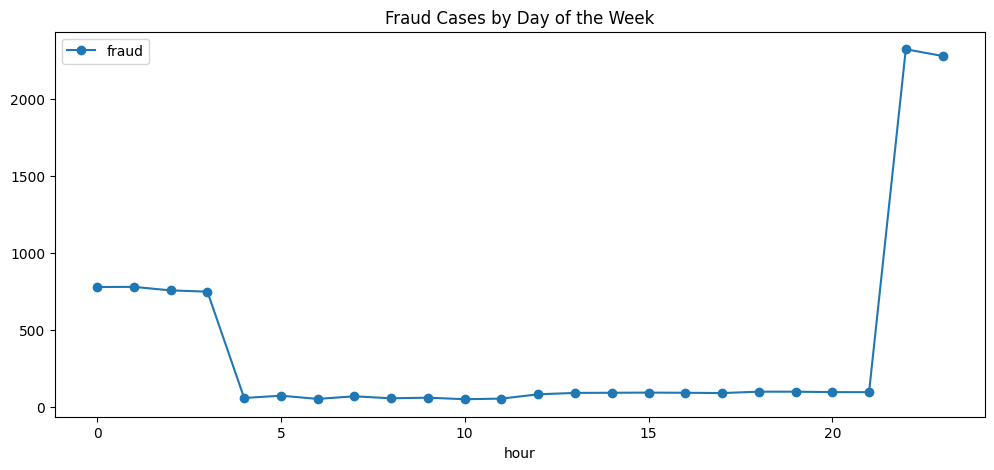

In [70]:
hour_pivot.plot(kind='line',x='hour',y='fraud',title='Fraud Cases by Day of the Week',marker='o',figsize=(12,5))

In [71]:
# 1. Create Pivot Table and Calculate Row Counts
day_pivot = df.pivot_table(index="day", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()
day_pivot.columns = ['day', 'not_fraud', 'fraud']
day_pivot.columns.name = None

# 2. Compute Global Totals
total_global_not_fraud = day_pivot['not_fraud'].sum()
total_global_fraud = day_pivot['fraud'].sum()

# 3. Calculate Proportions (Percentages)
day_pivot['per_not_fraud'] = day_pivot['not_fraud'] / total_global_not_fraud
day_pivot['per_fraud'] = day_pivot['fraud'] / total_global_fraud

# 4. Compute Weight of Evidence (WoE)
epsilon = 1e-4
day_pivot['WoE'] = np.log((day_pivot['per_not_fraud'] + epsilon) / (day_pivot['per_fraud'] + epsilon))

# 5. Map the Calculated WoE back to the Main DataFrame (FIXED)
day_woe_dict = dict(zip(day_pivot['day'], day_pivot['WoE']))
df['day_woe'] = df['day'].map(day_woe_dict)

# 6. Calculate and Print Total Information Value (IV)
day_iv = ((day_pivot['per_not_fraud'] - day_pivot['per_fraud']) * day_pivot['WoE']).sum()
print(f"Day IV: {day_iv:.4f}")

Day IV: 0.0302


In [72]:
day_pivot

,day,not_fraud,fraud,per_not_fraud,per_fraud,WoE
0,0,344482,1380,0.199473,0.152537,0.268121
1,1,252500,1204,0.146211,0.133083,0.094011
2,2,171407,1058,0.099254,0.116945,-0.163871
3,3,192537,1220,0.111489,0.134851,-0.190091
4,4,200202,1279,0.115928,0.141373,-0.198280
5,5,245249,1418,0.142012,0.156737,-0.098591
6,6,320581,1488,0.185633,0.164474,0.120949


<Axes: title={'center': 'Fraud Cases by Day of the Week'}, xlabel='day'>

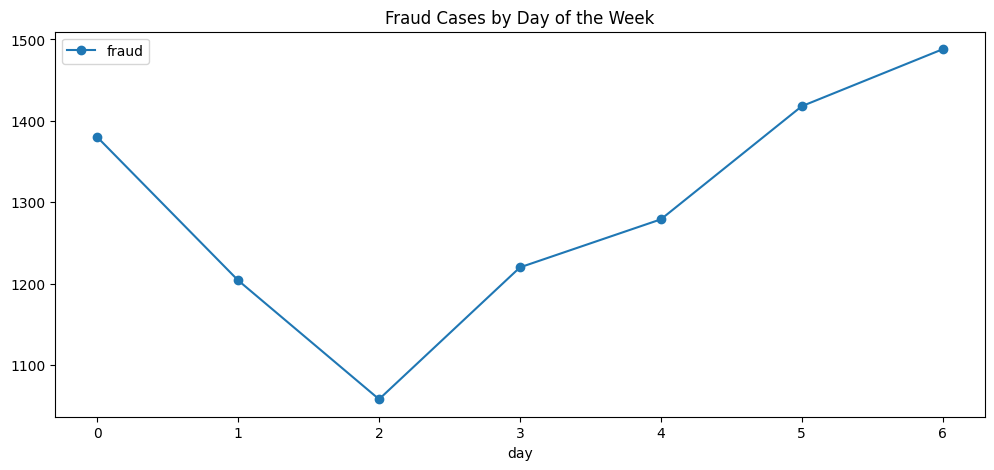

In [73]:
day_pivot.plot(kind='line',x='day',y='fraud',title='Fraud Cases by Day of the Week',marker='o',figsize=(12,5))

In [74]:
import numpy as np
import pandas as pd

# 1. Create Pivot Table and Calculate Row Counts
month_pivot = df.pivot_table(index="month", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()
month_pivot.columns = ['month', 'not_fraud', 'fraud']
month_pivot.columns.name = None

total_global_not_fraud = month_pivot['not_fraud'].sum()
total_global_fraud = month_pivot['fraud'].sum()

month_pivot['per_not_fraud'] = month_pivot['not_fraud'] / total_global_not_fraud
month_pivot['per_fraud'] = month_pivot['fraud'] / total_global_fraud

epsilon = 1e-4
month_pivot['WoE'] = np.log((month_pivot['per_not_fraud'] + epsilon) / (month_pivot['per_fraud'] + epsilon))

month_woe_dict = dict(zip(month_pivot['month'], month_pivot['WoE']))
df['month_woe'] = df['month'].map(month_woe_dict)

month_iv = ((month_pivot['per_not_fraud'] - month_pivot['per_fraud']) * month_pivot['WoE']).sum()
print(f"Month IV: {month_iv:.4f}")

Month IV: 0.0843


<Axes: title={'center': 'Fraud Cases by Month'}, xlabel='month'>

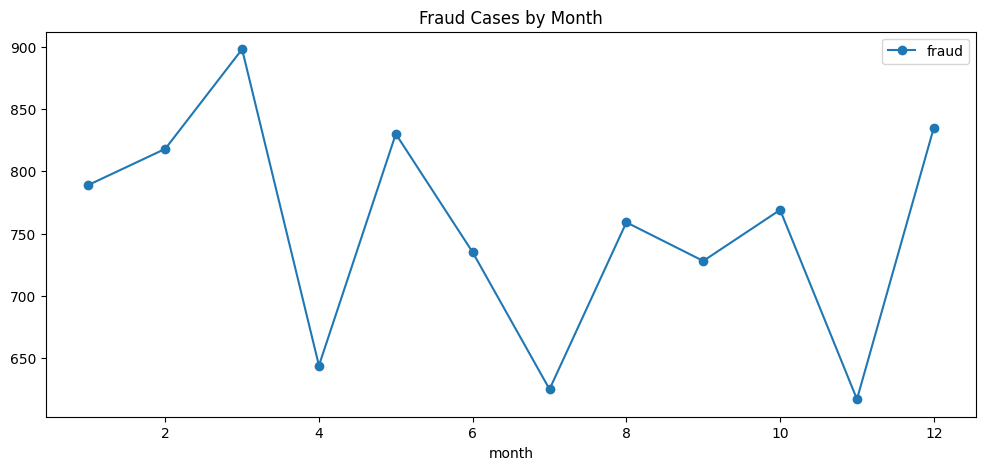

In [75]:
month_pivot.plot(kind='line',x='month',y='fraud',title='Fraud Cases by Month',marker='o',figsize=(12,5))

In [76]:
import numpy as np
import pandas as pd

year_pivot = df.pivot_table(index="year", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()
year_pivot.columns = ['year', 'not_fraud', 'fraud']
year_pivot.columns.name = None

total_global_not_fraud = year_pivot['not_fraud'].sum()
total_global_fraud = year_pivot['fraud'].sum()

year_pivot['per_not_fraud'] = year_pivot['not_fraud'] / total_global_not_fraud
year_pivot['per_fraud'] = year_pivot['fraud'] / total_global_fraud

epsilon = 1e-4
year_pivot['WoE'] = np.log((year_pivot['per_not_fraud'] + epsilon) / (year_pivot['per_fraud'] + epsilon))

year_woe_dict = dict(zip(year_pivot['year'], year_pivot['WoE']))
df['year_woe'] = df['year'].map(year_woe_dict)

year_iv = ((year_pivot['per_not_fraud'] - year_pivot['per_fraud']) * year_pivot['WoE']).sum()
print(f"Year IV: {year_iv:.4f}")

Year IV: 0.0086


In [77]:
import numpy as np
import pandas as pd

# 1. Create Pivot Table and Calculate Row Counts

R = 6371
lat1=np.radians(df['lat'])
lon1=np.radians(df['long'])
lat2=np.radians(df['merch_lat'])
lon2=np.radians(df['merch_long'])

dlat=lat2-lat1
dlong=lon2-lon1

a=np.sin(dlat/2)**2+np.cos(lat1)*np.cos(lat2)*np.sin(dlong/2)**2
d=2*np.arcsin(np.sqrt(a))
df['distance']=6371*d


distance_pivot = df.pivot_table(index="distance", columns="is_fraud", aggfunc="size", fill_value=0).reset_index()
distance_pivot.columns = ['distance', 'not_fraud', 'fraud']
distance_pivot.columns.name = None

# 2. Compute Global Totals
total_global_not_fraud = distance_pivot['not_fraud'].sum()
total_global_fraud = distance_pivot['fraud'].sum()

# 3. Calculate Proportions (Percentages)
distance_pivot['per_not_fraud'] = distance_pivot['not_fraud'] / total_global_not_fraud
distance_pivot['per_fraud'] = distance_pivot['fraud'] / total_global_fraud

# 4. Compute Weight of Evidence (WoE)
epsilon = 1e-4
distance_pivot['WoE'] = np.log((distance_pivot['per_not_fraud'] + epsilon) / (distance_pivot['per_fraud'] + epsilon))

# 5. Map the Calculated WoE back to the Main DataFrame (FIXED)
distance_woe_dict = dict(zip(distance_pivot['distance'], distance_pivot['WoE']))
df['distance_woe'] = df['distance'].map(distance_woe_dict)

# 6. Calculate and Print Total Information Value (IV)
distance_iv = ((distance_pivot['per_not_fraud'] - distance_pivot['per_fraud']) * distance_pivot['WoE']).sum()
print(f"Distance IV: {distance_iv:.4f}")

Distance IV: 0.7503


In [80]:
df.columns



Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'hour', 'day', 'month', 'year', 'is_night',
       'age', 'WoE', 'cat_woe', 'city_woe', 'age_woe', 'job_woe', 'zip_woe',
       'amt_bins', 'amt_bins_woe', 'pop_bins', 'pop_bins_woe', 'distance',
       'hour_woe', 'day_woe', 'month_woe', 'year_woe', 'distance_woe'],
      dtype='object')

In [89]:
required_columns = [
    'hour', 'day', 'month', 'year', 'is_night', 'merchant', 'category', 'amt',
    'gender', 'street', 'city', 'state', 'zip', 'lat',
    'long', 'city_pop', 'job', 'age', 'unix_time', 'merch_lat',
    'merch_long', 'distance', 'is_fraud'
]

In [91]:
data = df[required_columns].copy()
print(f"New dataset shape: {data.shape}")
print(data.columns)

New dataset shape: (1736005, 23)
Index(['hour', 'day', 'month', 'year', 'is_night', 'merchant', 'category',
       'amt', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long',
       'city_pop', 'job', 'age', 'unix_time', 'merch_lat', 'merch_long',
       'distance', 'is_fraud'],
      dtype='object')


In [92]:
data

,hour,day,month,year,is_night,merchant,category,amt,gender,street,...,lat,long,city_pop,job,age,unix_time,merch_lat,merch_long,distance,is_fraud
0,0,1,1,2019,1,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",38,1325376018,36.011293,-82.048315,78.597568,0
1,0,1,1,2019,1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,48,1325376044,49.159047,-118.186462,30.212176,0
2,0,1,1,2019,1,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,64,1325376051,43.150704,-112.154481,108.206083,0
3,0,1,1,2019,1,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,59,1325376076,47.034331,-112.561071,95.673231,0
4,0,1,1,2019,1,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,40,1325376186,38.674999,-78.632459,77.556744,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,23,3,12,2020,1,fraud_Reilly and Sons,health_fitness,43.77,M,558 Michael Estates,...,40.4931,-91.8912,519,Town planner,60,1388534347,39.946837,-91.333331,77.026148,0
1852390,23,3,12,2020,1,fraud_Hoppe-Parisian,kids_pets,111.84,M,572 Davis Mountains,...,29.0393,-95.4401,28739,Futures trader,27,1388534349,29.661049,-96.186633,100.074420,0
1852391,23,3,12,2020,1,fraud_Rau-Robel,kids_pets,86.88,F,144 Evans Islands Apt. 683,...,46.1966,-118.9017,3684,Musician,45,1388534355,46.658340,-119.715054,80.759302,0
1852392,23,3,12,2020,1,fraud_Breitenberg LLC,travel,7.99,M,7020 Doyle Stream Apt. 951,...,44.6255,-116.4493,129,Cartographer,61,1388534364,44.470525,-117.080888,52.933240,0


In [93]:
data.columns

Index(['hour', 'day', 'month', 'year', 'is_night', 'merchant', 'category',
       'amt', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long',
       'city_pop', 'job', 'age', 'unix_time', 'merch_lat', 'merch_long',
       'distance', 'is_fraud'],
      dtype='object')

In [94]:
s3_destination_path="s3://fraud-detection-pipeline-anish-964043552068-ap-south-1-an/processed_data/processed_data.parquet"

aws_credentials = {
    "key": os.getenv("AWS_ACCESS_KEY_ID"),
    "secret": os.getenv("AWS_SECRET_ACCESS_KEY"),
    "client_kwargs": {
        "region_name": os.getenv("AWS_DEFAULT_REGION")
    }
}
data.to_parquet(s3_destination_path,
                engine='fastparquet',
                index=False,
                storage_options=aws_credentials)

In [86]:
data

,hour,day,month,year,is_night,amt,city_pop,age,distance,unix_time,lat,long,merch_lat,merch_long,category,city,job,state,zip,is_fraud
0,0,1,1,2019,1,4.97,3495,38,78.597568,1325376018,36.0788,-81.1781,36.011293,-82.048315,misc_net,Moravian Falls,"Psychologist, counselling",NC,28654,0
1,0,1,1,2019,1,107.23,149,48,30.212176,1325376044,48.8878,-118.2105,49.159047,-118.186462,grocery_pos,Orient,Special educational needs teacher,WA,99160,0
2,0,1,1,2019,1,220.11,4154,64,108.206083,1325376051,42.1808,-112.2620,43.150704,-112.154481,entertainment,Malad City,Nature conservation officer,ID,83252,0
3,0,1,1,2019,1,45.00,1939,59,95.673231,1325376076,46.2306,-112.1138,47.034331,-112.561071,gas_transport,Boulder,Patent attorney,MT,59632,0
4,0,1,1,2019,1,41.96,99,40,77.556744,1325376186,38.4207,-79.4629,38.674999,-78.632459,misc_pos,Doe Hill,Dance movement psychotherapist,VA,24433,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,23,3,12,2020,1,43.77,519,60,77.026148,1388534347,40.4931,-91.8912,39.946837,-91.333331,health_fitness,Luray,Town planner,MO,63453,0
1852390,23,3,12,2020,1,111.84,28739,27,100.074420,1388534349,29.0393,-95.4401,29.661049,-96.186633,kids_pets,Lake Jackson,Futures trader,TX,77566,0
1852391,23,3,12,2020,1,86.88,3684,45,80.759302,1388534355,46.1966,-118.9017,46.658340,-119.715054,kids_pets,Burbank,Musician,WA,99323,0
1852392,23,3,12,2020,1,7.99,129,61,52.933240,1388534364,44.6255,-116.4493,44.470525,-117.080888,travel,Mesa,Cartographer,ID,83643,0
